**1. Оберіть ваш варіант та завантажте необхідний файл з даними.**


**2. Проаналізуйте приклад використання згорткової нейронної мережі для класифікації зображень.**


**3. Проаналізуйте приклад використання підходу Transfer Learning для класифікації зображень CIFAR-10.**


**4. Розробка власної CNN архітектури:**

- Побудуйте модель, що містить мінімум 3 згорткові блоки (один блок складається з такої послідовності шарів: Conv, BatchNorm, ReLU, MaxPool).
- Використайте Global Average Pooling замість класичного Flatten перед повнозв'язним шаром та порівняйте кількість параметрів мережі в обох випадках.
- Реалізуйте цикл навчання з використанням Optimizer та Scheduler із бібліотеки PyTorch.


Нижче — завантаження зображень з каталогу `dataset` (класи — підпапки, 150 класів). Після виконання клітинки з кодом доступні `num_classes`, `class_names`, `train_loader` та `val_loader`. Запускайте ноутбук з папки `ЛР-5` (або змініть у коді `DATA_DIR` на повний шлях до `dataset`). Зображення приводяться до 32×32 під архітектуру CNN нижче.


In [1]:
import torch
from pathlib import Path
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

DATA_DIR = Path("dataset")

train_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

full_dataset = ImageFolder(root=str(DATA_DIR.resolve()), transform=train_transform)
class_names = full_dataset.classes
num_classes = len(class_names)

val_ratio = 0.2
n_val = int(len(full_dataset) * val_ratio)
n_train = len(full_dataset) - n_val
train_dataset, val_dataset = random_split(
    full_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42),
)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

n_train, n_val, num_classes

(2928, 731, 150)

In [13]:
import torch
import torch.nn as nn

def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

class ConvBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.pool(x)
        return x

class CNNFlatten(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.block1 = ConvBlock(3, 32)
        self.block2 = ConvBlock(32, 64)
        self.block3 = ConvBlock(64, 128)
        self.fc = nn.Linear(128 * 4 * 4, num_classes)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

class CNNGAP(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.block1 = ConvBlock(3, 32)
        self.block2 = ConvBlock(32, 64)
        self.block3 = ConvBlock(64, 128)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, num_classes)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


def compare_flat_vs_gap(num_classes: int) -> None:
    flat = CNNFlatten(num_classes)
    gap = CNNGAP(num_classes)
    n_flat = count_parameters(flat)
    n_gap = count_parameters(gap)
    fc_flat = flat.fc.weight.numel() + flat.fc.bias.numel()
    fc_gap = gap.fc.weight.numel() + gap.fc.bias.numel()
    print(f"num_classes={num_classes}")
    print(f"CNNFlatten (усього): {n_flat:,}")
    print(f"CNNGAP (усього):     {n_gap:,}")
    print(f"Різниця (Flatten−GAP): {n_flat - n_gap:,}")
    print(f"Частка параметрів GAP до Flatten: {n_gap / n_flat:.6f}")
    print(f"Параметри лише fc у Flatten: {fc_flat:,}")
    print(f"Параметри лише fc у GAP:     {fc_gap:,}")

In [14]:
compare_flat_vs_gap(num_classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes=150
CNNFlatten (усього): 400,822
CNNGAP (усього):     112,822
Різниця (Flatten−GAP): 288,000
Частка параметрів GAP до Flatten: 0.281477
Параметри лише fc у Flatten: 307,350
Параметри лише fc у GAP:     19,350


In [15]:
from __future__ import annotations

import torch
import torch.nn as nn
from copy import deepcopy
import time
from typing import Tuple

from torch.utils.data import DataLoader


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer | None,
    device: torch.device,
    train: bool,
) -> Tuple[float, float]:
    if train:
        model.train()
    else:
        model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            if train and optimizer is not None:
                optimizer.zero_grad(set_to_none=True)
            outputs = model(images)
            loss = criterion(outputs, labels)
            if train and optimizer is not None:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            pred = outputs.argmax(dim=1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total


def fit(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int,
    lr: float,
    device: torch.device,
) -> dict[str, list[float]]:
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=max(1, epochs // 2), gamma=0.5
    )
    history: dict[str, list[float]] = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }
    best_state: dict[str, torch.Tensor] | None = None
    best_val = 0.0
    for epoch in range(epochs):
        tr_loss, tr_acc = run_epoch(
            model, train_loader, criterion, optimizer, device, True
        )
        va_loss, va_acc = run_epoch(
            model, val_loader, criterion, None, device, False
        )
        scheduler.step()
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)
        lr_cur = scheduler.get_last_lr()[0]
        print(
            f"epoch {epoch + 1}/{epochs} lr={lr_cur:.6f} "
            f"train_loss={tr_loss:.4f} val_loss={va_loss:.4f} "
            f"train_acc={tr_acc:.4f} val_acc={va_acc:.4f}"
        )
        if va_acc > best_val:
            best_val = va_acc
            best_state = deepcopy(model.state_dict())
    if best_state is not None:
        model.load_state_dict(best_state)
    return history


epochs = 10
lr = 1e-3
torch.manual_seed(42)
model_flat = CNNFlatten(num_classes).to(device)
model_gap = CNNGAP(num_classes).to(device)
print("CNNFlatten")
t0 = time.perf_counter()
training_history_flat = fit(model_flat, train_loader, val_loader, epochs, lr, device)
time_cnn_flat = time.perf_counter() - t0
print("CNNGAP")
t0 = time.perf_counter()
training_history_gap = fit(model_gap, train_loader, val_loader, epochs, lr, device)
time_cnn_gap = time.perf_counter() - t0

CNNFlatten
epoch 1/10 lr=0.001000 train_loss=4.2044 val_loss=2.6337 train_acc=0.1803 val_acc=0.3748
epoch 2/10 lr=0.001000 train_loss=1.6579 val_loss=1.5649 train_acc=0.6120 val_acc=0.6375
epoch 3/10 lr=0.001000 train_loss=0.6698 val_loss=0.9154 train_acc=0.8398 val_acc=0.7866
epoch 4/10 lr=0.001000 train_loss=0.3239 val_loss=0.7096 train_acc=0.9331 val_acc=0.8523
epoch 5/10 lr=0.000500 train_loss=0.1428 val_loss=0.6874 train_acc=0.9778 val_acc=0.8358
epoch 6/10 lr=0.000500 train_loss=0.0618 val_loss=0.4999 train_acc=0.9932 val_acc=0.8892
epoch 7/10 lr=0.000500 train_loss=0.0353 val_loss=0.4894 train_acc=0.9973 val_acc=0.8974
epoch 8/10 lr=0.000500 train_loss=0.0256 val_loss=0.4882 train_acc=0.9993 val_acc=0.9070
epoch 9/10 lr=0.000500 train_loss=0.0191 val_loss=0.4814 train_acc=0.9997 val_acc=0.9001
epoch 10/10 lr=0.000250 train_loss=0.0163 val_loss=0.4876 train_acc=0.9997 val_acc=0.9070
CNNGAP
epoch 1/10 lr=0.001000 train_loss=4.6214 val_loss=4.2497 train_acc=0.0523 val_acc=0.0725
ep

**5. Дослідження підходу Transfer Learning:**

- Оберіть попередньо навчену модель (наприклад, ResNet18 або MobileNetV2).
- Реалізуйте стратегію Feature Extraction (заморозивши всі шари, крім останнього шару).
- Реалізуйте стратегію Fine-tuning (розморозивши лише останні блоки згортки, наприклад, layer4 у ResNet).
- Порівняйте точність та швидкість збіжності цих двох підходів порівняно з вашою власною архітектурою з пункту 4.


In [16]:
import time
from typing import Callable

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from torchvision.models import mobilenet_v2, resnet18
from torchvision.models import MobileNet_V2_Weights, ResNet18_Weights

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

tl_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

full_tl = ImageFolder(root=str(DATA_DIR.resolve()), transform=tl_transform)
train_tl, val_tl = random_split(
    full_tl,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42),
)
train_loader_tl = DataLoader(train_tl, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader_tl = DataLoader(val_tl, batch_size=batch_size, shuffle=False, num_workers=0)


def fit_trainable(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int,
    lr: float,
    device: torch.device,
) -> dict[str, list[float]]:
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad], lr=lr
    )
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=max(1, epochs // 2), gamma=0.5
    )
    history: dict[str, list[float]] = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }
    best_state: dict[str, torch.Tensor] | None = None
    best_val = 0.0
    for epoch in range(epochs):
        tr_loss, tr_acc = run_epoch(
            model, train_loader, criterion, optimizer, device, True
        )
        va_loss, va_acc = run_epoch(
            model, val_loader, criterion, None, device, False
        )
        scheduler.step()
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)
        lr_cur = scheduler.get_last_lr()[0]
        print(
            f"epoch {epoch + 1}/{epochs} lr={lr_cur:.6f} "
            f"train_loss={tr_loss:.4f} val_loss={va_loss:.4f} "
            f"train_acc={tr_acc:.4f} val_acc={va_acc:.4f}"
        )
        if va_acc > best_val:
            best_val = va_acc
            best_state = deepcopy(model.state_dict())
    if best_state is not None:
        model.load_state_dict(best_state)
    return history


def set_resnet_fe(model: nn.Module) -> None:
    for p in model.parameters():
        p.requires_grad = False
    for p in model.fc.parameters():
        p.requires_grad = True


def set_resnet_ft(model: nn.Module) -> None:
    for p in model.parameters():
        p.requires_grad = False
    for p in model.layer4.parameters():
        p.requires_grad = True
    for p in model.fc.parameters():
        p.requires_grad = True


def set_mnv2_fe(model: nn.Module) -> None:
    for p in model.parameters():
        p.requires_grad = False
    for p in model.classifier.parameters():
        p.requires_grad = True


def set_mnv2_ft(model: nn.Module) -> None:
    for p in model.parameters():
        p.requires_grad = False
    for p in model.features[-1].parameters():
        p.requires_grad = True
    for p in model.classifier.parameters():
        p.requires_grad = True


def make_resnet(num_classes: int) -> nn.Module:
    m = resnet18(weights=ResNet18_Weights.DEFAULT)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m


def make_mnv2(num_classes: int) -> nn.Module:
    m = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
    in_f = m.classifier[1].in_features
    m.classifier[1] = nn.Linear(in_f, num_classes)
    return m


def run_tl_experiment(
    name: str,
    build: Callable[[int], nn.Module],
    setup: Callable[[nn.Module], None],
    epochs_tl: int,
    lr_tl: float,
    device: torch.device,
) -> tuple[nn.Module, dict[str, list[float]], float]:
    torch.manual_seed(42)
    model = build(num_classes).to(device)
    setup(model)
    n_tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(name, "trainable params:", n_tr)
    t0 = time.perf_counter()
    hist = fit_trainable(
        model, train_loader_tl, val_loader_tl, epochs_tl, lr_tl, device
    )
    elapsed = time.perf_counter() - t0
    return model, hist, elapsed


epochs_tl = 10
lr_fe = 1e-3
lr_ft = 1e-4

model_r18_fe, hist_r18_fe, time_r18_fe = run_tl_experiment(
    "ResNet18 feature extraction", make_resnet, set_resnet_fe, epochs_tl, lr_fe, device
)
model_r18_ft, hist_r18_ft, time_r18_ft = run_tl_experiment(
    "ResNet18 fine-tuning", make_resnet, set_resnet_ft, epochs_tl, lr_ft, device
)
model_m2_fe, hist_m2_fe, time_m2_fe = run_tl_experiment(
    "MobileNetV2 feature extraction", make_mnv2, set_mnv2_fe, epochs_tl, lr_fe, device
)
model_m2_ft, hist_m2_ft, time_m2_ft = run_tl_experiment(
    "MobileNetV2 fine-tuning", make_mnv2, set_mnv2_ft, epochs_tl, lr_ft, device
)

tl_runs: dict[str, tuple[dict[str, list[float]], float]] = {
    "ResNet18 FE": (hist_r18_fe, time_r18_fe),
    "ResNet18 FT": (hist_r18_ft, time_r18_ft),
    "MobileNetV2 FE": (hist_m2_fe, time_m2_fe),
    "MobileNetV2 FT": (hist_m2_ft, time_m2_ft),
}

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\vikto/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:07<00:00, 6.56MB/s]


ResNet18 feature extraction trainable params: 76950
epoch 1/10 lr=0.001000 train_loss=4.2730 val_loss=3.1799 train_acc=0.1844 val_acc=0.4473
epoch 2/10 lr=0.001000 train_loss=2.3244 val_loss=2.0463 train_acc=0.6568 val_acc=0.6990
epoch 3/10 lr=0.001000 train_loss=1.3675 val_loss=1.4926 train_acc=0.8371 val_acc=0.7688
epoch 4/10 lr=0.001000 train_loss=0.9033 val_loss=1.2356 train_acc=0.9071 val_acc=0.7825
epoch 5/10 lr=0.000500 train_loss=0.6405 val_loss=1.0105 train_acc=0.9409 val_acc=0.8331
epoch 6/10 lr=0.000500 train_loss=0.4946 val_loss=0.9122 train_acc=0.9628 val_acc=0.8632
epoch 7/10 lr=0.000500 train_loss=0.4347 val_loss=0.8472 train_acc=0.9672 val_acc=0.8673
epoch 8/10 lr=0.000500 train_loss=0.3859 val_loss=0.8229 train_acc=0.9730 val_acc=0.8687
epoch 9/10 lr=0.000500 train_loss=0.3417 val_loss=0.7810 train_acc=0.9802 val_acc=0.8769
epoch 10/10 lr=0.000250 train_loss=0.3017 val_loss=0.7544 train_acc=0.9846 val_acc=0.8796
ResNet18 fine-tuning trainable params: 8470678
epoch 1/10

100%|██████████| 13.6M/13.6M [00:01<00:00, 7.90MB/s]


MobileNetV2 feature extraction trainable params: 192150
epoch 1/10 lr=0.001000 train_loss=4.2023 val_loss=3.2486 train_acc=0.2275 val_acc=0.5705
epoch 2/10 lr=0.001000 train_loss=2.5233 val_loss=2.2787 train_acc=0.7135 val_acc=0.7237
epoch 3/10 lr=0.001000 train_loss=1.6244 val_loss=1.6743 train_acc=0.8531 val_acc=0.8085
epoch 4/10 lr=0.001000 train_loss=1.1457 val_loss=1.4059 train_acc=0.9010 val_acc=0.8194
epoch 5/10 lr=0.000500 train_loss=0.8463 val_loss=1.1712 train_acc=0.9358 val_acc=0.8413
epoch 6/10 lr=0.000500 train_loss=0.6711 val_loss=1.0886 train_acc=0.9566 val_acc=0.8454
epoch 7/10 lr=0.000500 train_loss=0.5964 val_loss=1.0543 train_acc=0.9628 val_acc=0.8440
epoch 8/10 lr=0.000500 train_loss=0.5198 val_loss=0.9910 train_acc=0.9699 val_acc=0.8509
epoch 9/10 lr=0.000500 train_loss=0.4754 val_loss=0.9353 train_acc=0.9727 val_acc=0.8591
epoch 10/10 lr=0.000250 train_loss=0.4253 val_loss=0.9070 train_acc=0.9747 val_acc=0.8646
MobileNetV2 fine-tuning trainable params: 604310
epoc

**6. Аналіз результатів та візуалізація:**

- Побудуйте графіки функцій втрат (Loss) та точності (Accuracy) для всіх експериментів.
- Побудуйте Confusion Matrix для фінальної моделі та проаналізуйте, які класи об'єктів модель плутає найчастіше.

_Числові підсумки (точність, час) — у таблицях; криві loss/accuracy — на графіках._


,Експеримент,Час навчання (с),Найкраща val acc (епоха),Accuracy (val),Precision macro,Recall macro,F1 macro,Найкраща train acc
0,CNNFlatten,59.2,0.9070,0.9070,0.8752,0.8828,0.8675,0.9997
1,CNNGAP,55.4,0.5021,0.5021,0.4469,0.4345,0.4046,0.6148
2,ResNet18 FE,763.7,0.8796,0.8796,0.8676,0.8644,0.8516,0.9846
3,ResNet18 FT,999.4,0.9521,0.9521,0.9170,0.9243,0.9121,1.0000
4,MobileNetV2 FE,714.5,0.8646,0.8646,0.8608,0.8415,0.8379,0.9747
5,MobileNetV2 FT,736.1,0.6936,0.6936,0.6964,0.6326,0.6231,0.7964


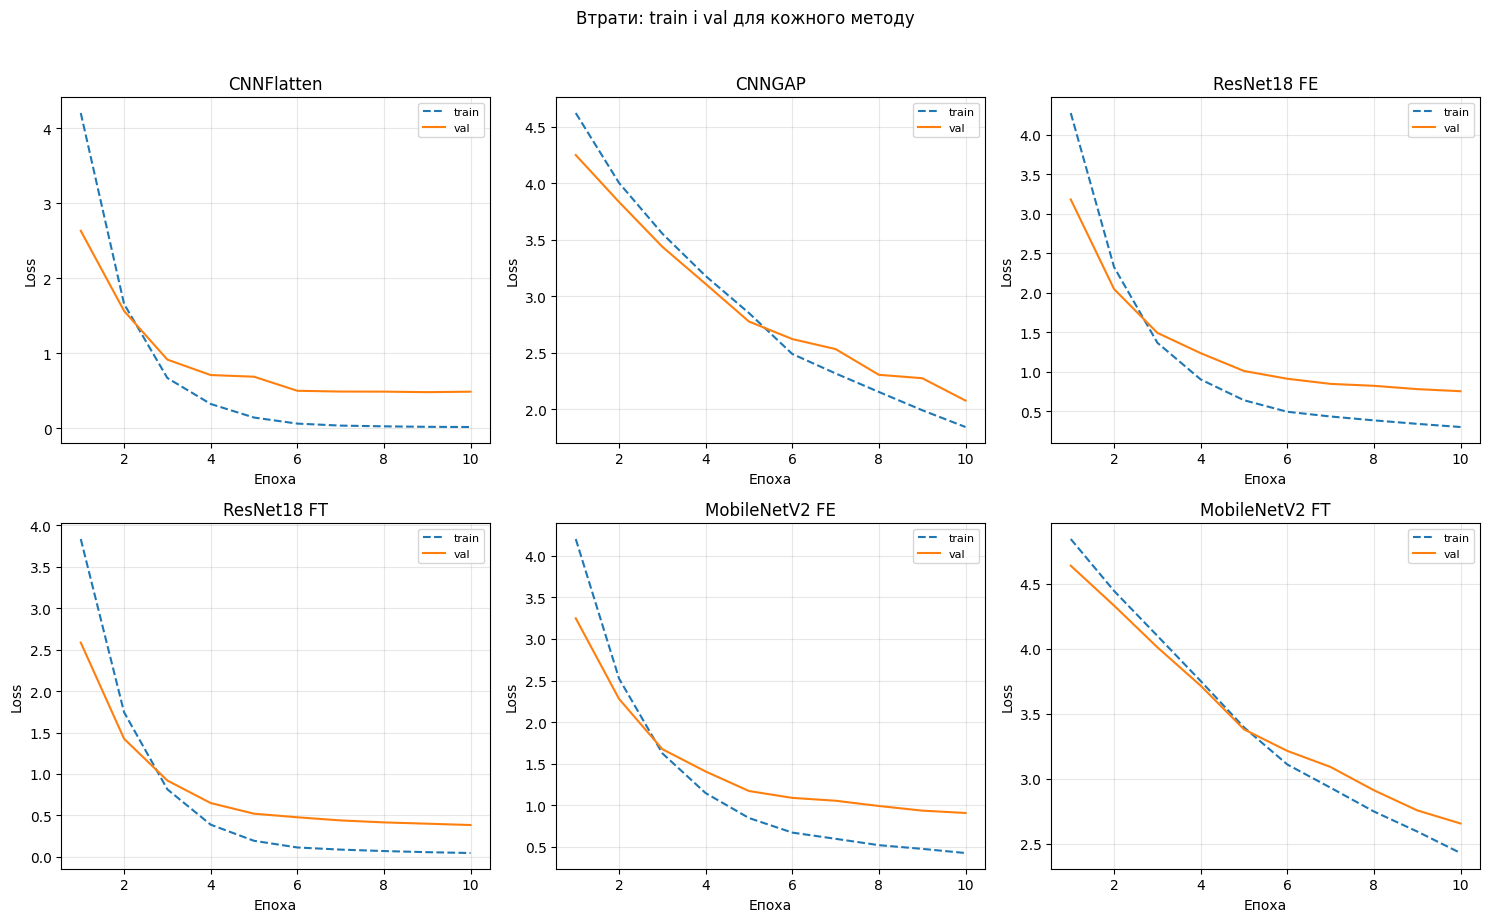

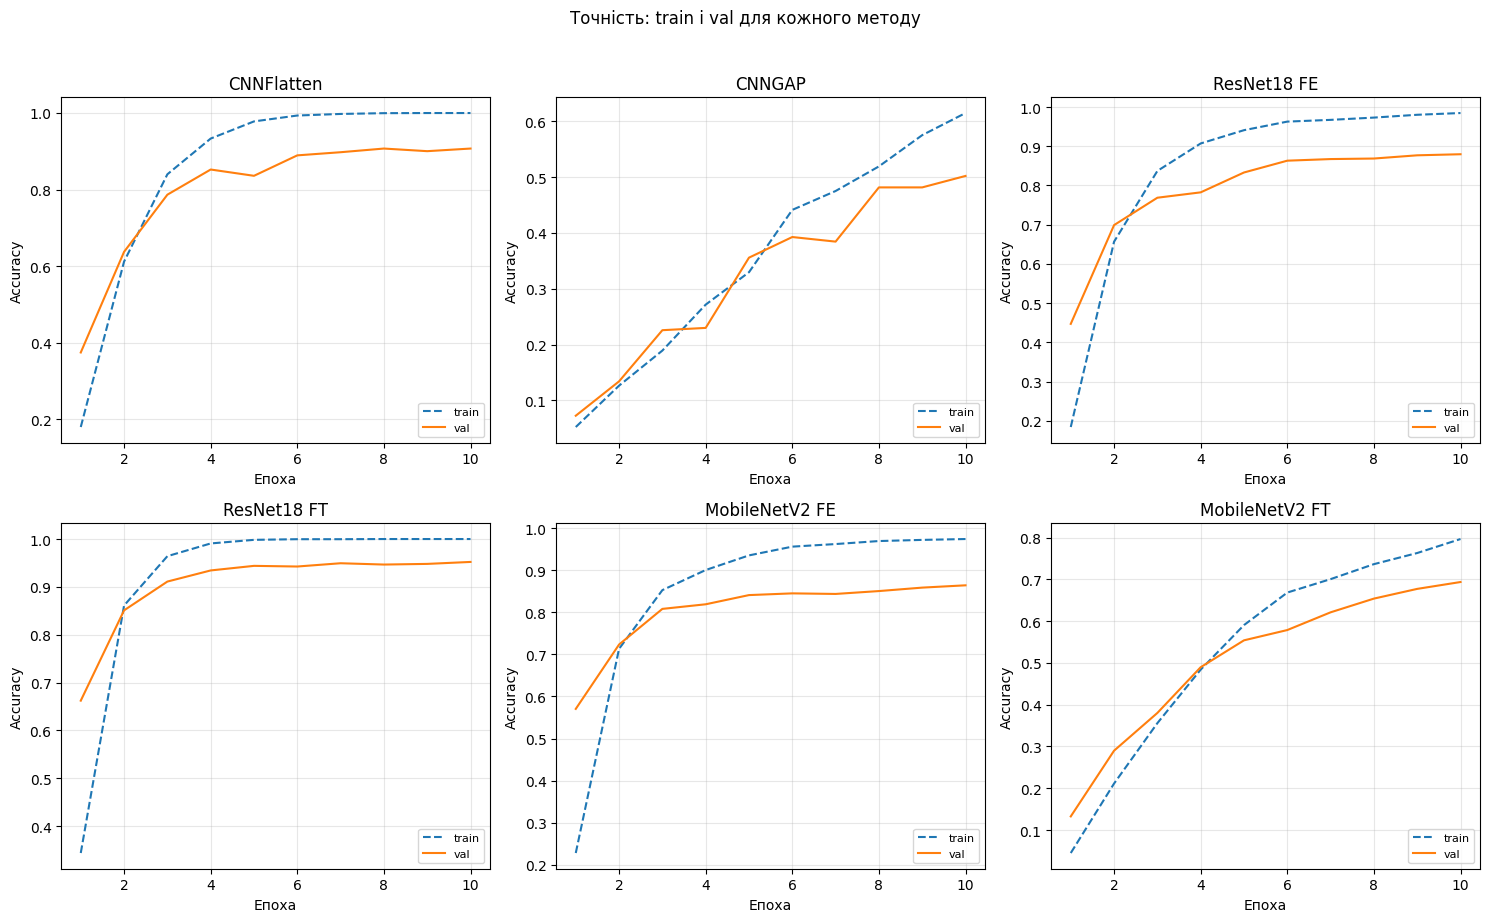

Найкраща модель для CM: ResNet18 FT accuracy 0.9521 precision 0.917 recall 0.9243 f1 0.9121


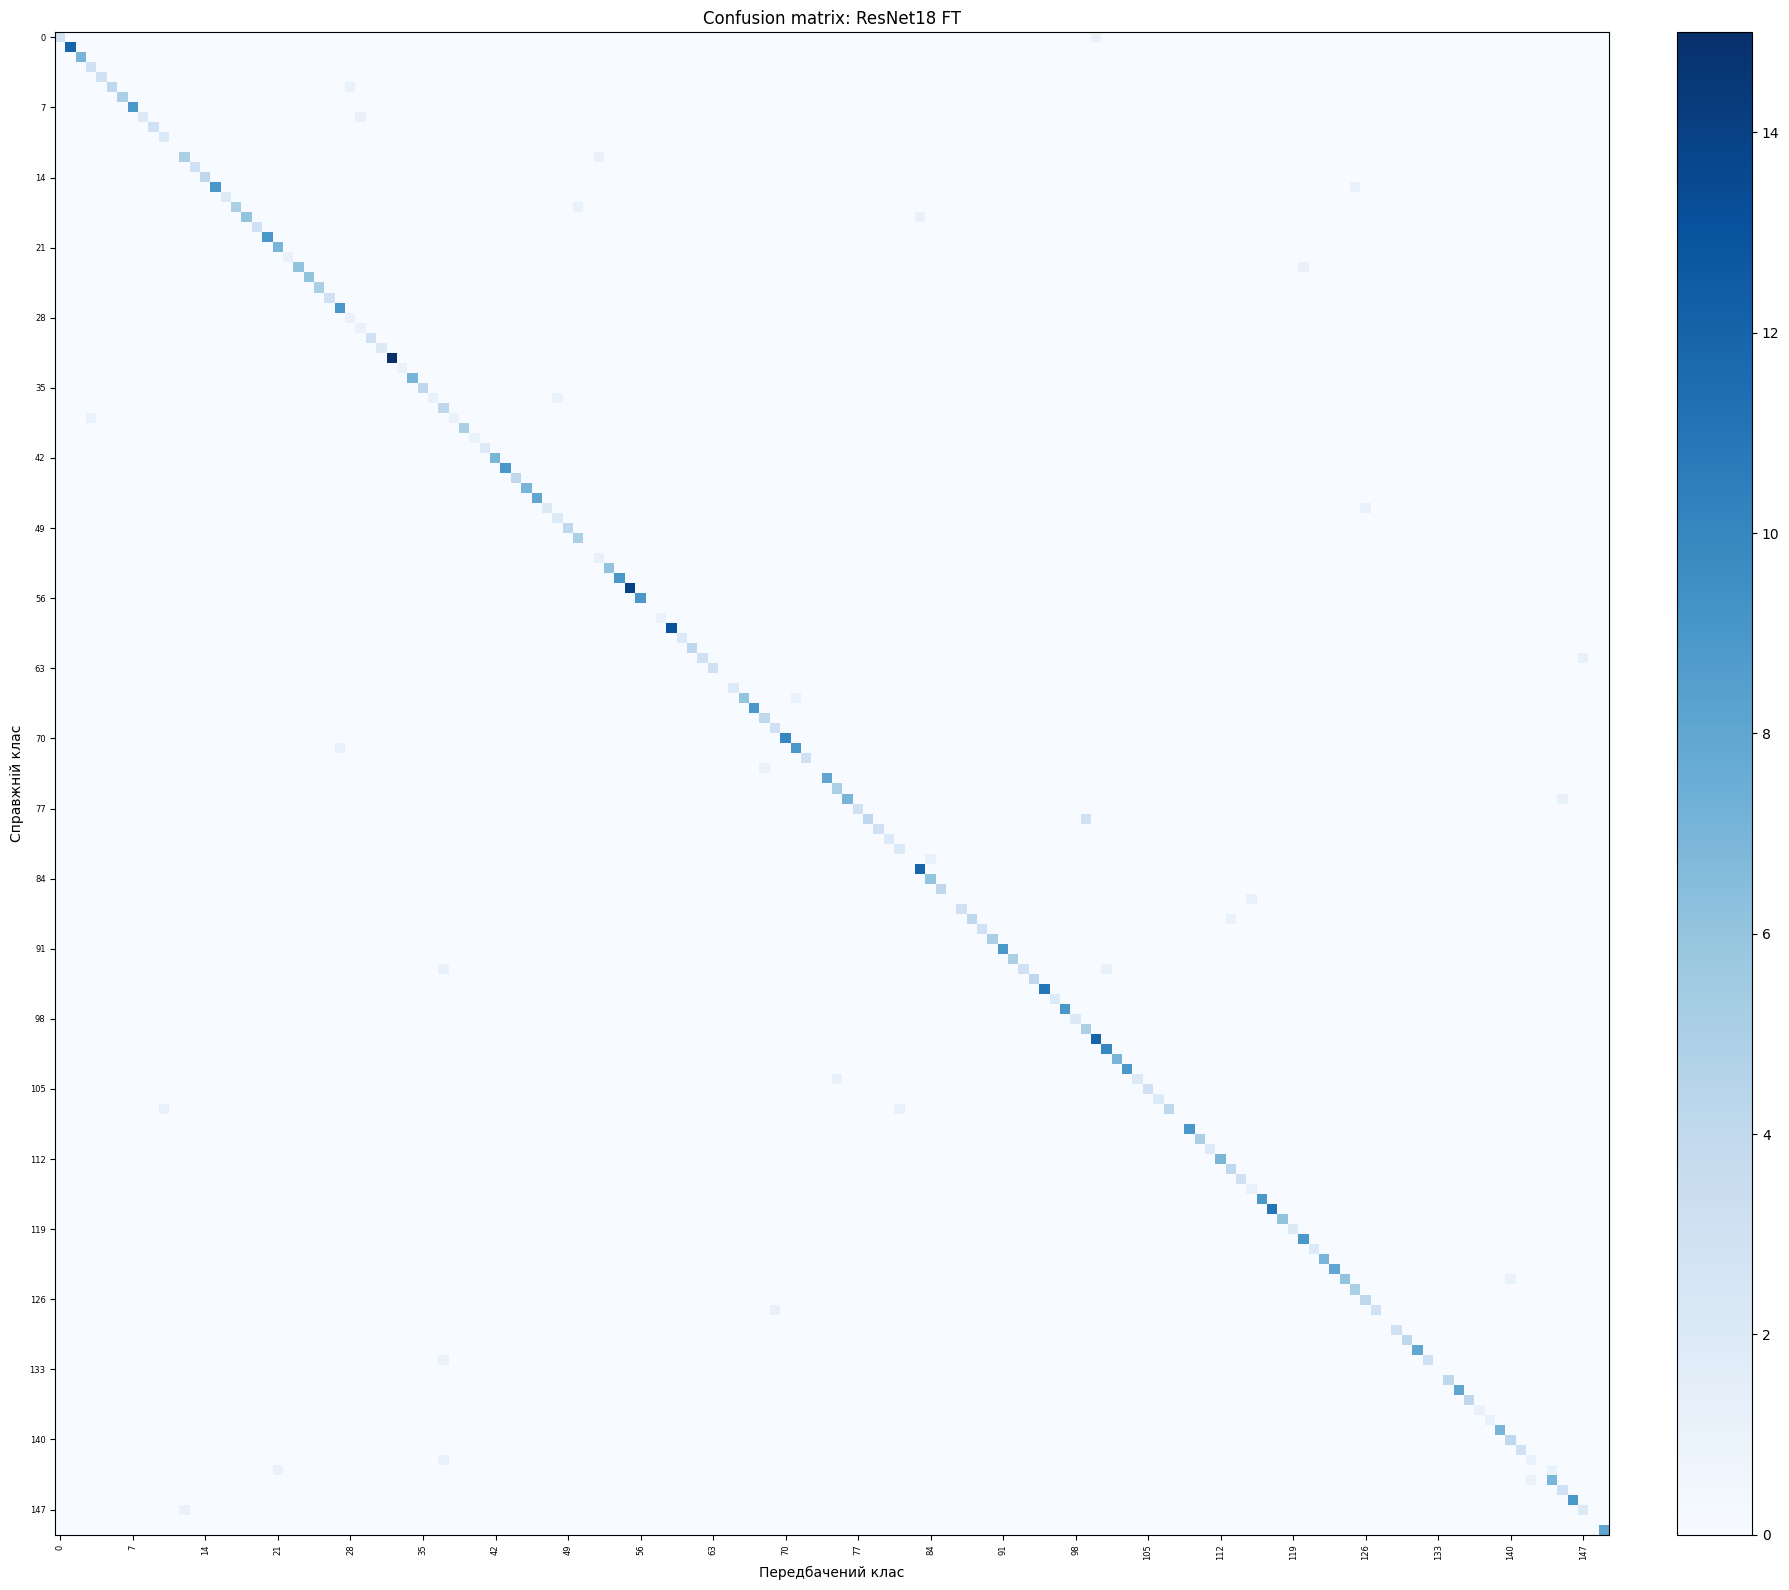

Топ плутанин (справжній -> передбачений, кількість):
drowzee -> electabuzz 3
fraxure -> cottonee 1
flygon -> florges 1
flutter-mane -> flygon 1
flutter-mane -> crobat 1
florges -> darumaka 1
flabebe -> darumaka 1
ferrothorn -> drampa 1
fennekin -> floette 1
empoleon -> ducklett 1


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from torch.utils.data import DataLoader


def collect_predictions(
    model: nn.Module, loader: DataLoader, device: torch.device
) -> tuple[list[int], list[int]]:
    y_true: list[int] = []
    y_pred: list[int] = []
    model.eval()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x)
            y_true.extend(y.cpu().numpy().tolist())
            y_pred.extend(out.argmax(dim=1).cpu().numpy().tolist())
    return y_true, y_pred


def metrics_from_lists(y_true: list[int], y_pred: list[int]) -> dict[str, float]:
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision_macro": float(
            precision_score(y_true, y_pred, average="macro", zero_division=0)
        ),
        "recall_macro": float(
            recall_score(y_true, y_pred, average="macro", zero_division=0)
        ),
        "f1_macro": float(
            f1_score(y_true, y_pred, average="macro", zero_division=0)
        ),
    }


def val_metrics(model: nn.Module, loader: DataLoader, device: torch.device) -> dict[str, float]:
    y_true, y_pred = collect_predictions(model, loader, device)
    return metrics_from_lists(y_true, y_pred)


all_experiments: dict[str, tuple[dict[str, list[float]], float]] = {
    "CNNFlatten": (training_history_flat, time_cnn_flat),
    "CNNGAP": (training_history_gap, time_cnn_gap),
    **tl_runs,
}

experiment_order = [
    "CNNFlatten",
    "CNNGAP",
    "ResNet18 FE",
    "ResNet18 FT",
    "MobileNetV2 FE",
    "MobileNetV2 FT",
]

models_and_loaders: dict[str, tuple[nn.Module, DataLoader]] = {
    "CNNFlatten": (model_flat, val_loader),
    "CNNGAP": (model_gap, val_loader),
    "ResNet18 FE": (model_r18_fe, val_loader_tl),
    "ResNet18 FT": (model_r18_ft, val_loader_tl),
    "MobileNetV2 FE": (model_m2_fe, val_loader_tl),
    "MobileNetV2 FT": (model_m2_ft, val_loader_tl),
}

rows = []
for name in experiment_order:
    hist, sec = all_experiments[name]
    model, loader = models_and_loaders[name]
    vm = val_metrics(model, loader, device)
    rows.append(
        {
            "Експеримент": name,
            "Час навчання (с)": round(sec, 1),
            "Найкраща val acc (епоха)": round(max(hist["val_acc"]), 4),
            "Accuracy (val)": round(vm["accuracy"], 4),
            "Precision macro": round(vm["precision_macro"], 4),
            "Recall macro": round(vm["recall_macro"], 4),
            "F1 macro": round(vm["f1_macro"], 4),
            "Найкраща train acc": round(max(hist["train_acc"]), 4),
        }
    )
summary_df = pd.DataFrame(rows)
display(summary_df)

fig_loss, axes_loss = plt.subplots(2, 3, figsize=(15, 9))
for ax, name in zip(axes_loss.flatten(), experiment_order):
    hist = all_experiments[name][0]
    xs = np.arange(1, len(hist["val_loss"]) + 1)
    ax.plot(xs, hist["train_loss"], label="train", linestyle="--")
    ax.plot(xs, hist["val_loss"], label="val")
    ax.set_xlabel("Епоха")
    ax.set_ylabel("Loss")
    ax.set_title(name)
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle("Втрати: train і val для кожного методу", y=1.02)
plt.tight_layout()
plt.show()

fig_acc, axes_acc = plt.subplots(2, 3, figsize=(15, 9))
for ax, name in zip(axes_acc.flatten(), experiment_order):
    hist = all_experiments[name][0]
    xs = np.arange(1, len(hist["val_acc"]) + 1)
    ax.plot(xs, hist["train_acc"], label="train", linestyle="--")
    ax.plot(xs, hist["val_acc"], label="val")
    ax.set_xlabel("Епоха")
    ax.set_ylabel("Accuracy")
    ax.set_title(name)
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle("Точність: train і val для кожного методу", y=1.02)
plt.tight_layout()
plt.show()

candidates: list[tuple[str, nn.Module, DataLoader]] = [
    (name, models_and_loaders[name][0], models_and_loaders[name][1])
    for name in experiment_order
]
best_name, best_model, best_loader = max(
    candidates,
    key=lambda item: val_metrics(item[1], item[2], device)["f1_macro"],
)
bm = val_metrics(best_model, best_loader, device)
print(
    "Найкраща модель для CM:",
    best_name,
    "accuracy",
    round(bm["accuracy"], 4),
    "precision",
    round(bm["precision_macro"], 4),
    "recall",
    round(bm["recall_macro"], 4),
    "f1",
    round(bm["f1_macro"], 4),
)

y_true, y_pred = collect_predictions(best_model, best_loader, device)

cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
plt.figure(figsize=(18, 16))
plt.imshow(cm, cmap="Blues", aspect="auto")
plt.colorbar(fraction=0.046, pad=0.04)
plt.xlabel("Передбачений клас")
plt.ylabel("Справжній клас")
plt.title(f"Confusion matrix: {best_name}")
step = max(1, num_classes // 20)
plt.xticks(np.arange(0, num_classes, step), rotation=90, fontsize=6)
plt.yticks(np.arange(0, num_classes, step), fontsize=6)
plt.tight_layout()
plt.show()

pairs = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j:
            pairs.append((cm[i, j], i, j))
pairs.sort(reverse=True)
print("Топ плутанин (справжній -> передбачений, кількість):")
for cnt, i, j in pairs[:10]:
    if cnt <= 0:
        break
    print(class_names[i], "->", class_names[j], int(cnt))

In [20]:
from pathlib import Path

import torch
import torch.nn as nn

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)


def save_checkpoint(path: Path, model: nn.Module) -> None:
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "class_names": class_names,
            "num_classes": num_classes,
        },
        path,
    )


save_checkpoint(MODELS_DIR / "cnn_flatten.pt", model_flat)
save_checkpoint(MODELS_DIR / "cnn_gap.pt", model_gap)
save_checkpoint(MODELS_DIR / "resnet18_fe.pt", model_r18_fe)
save_checkpoint(MODELS_DIR / "resnet18_ft.pt", model_r18_ft)
save_checkpoint(MODELS_DIR / "mobilenetv2_fe.pt", model_m2_fe)
save_checkpoint(MODELS_DIR / "mobilenetv2_ft.pt", model_m2_ft)
list(MODELS_DIR.glob("*.pt"))

[WindowsPath('models/cnn_flatten.pt'),
 WindowsPath('models/cnn_gap.pt'),
 WindowsPath('models/mobilenetv2_fe.pt'),
 WindowsPath('models/mobilenetv2_ft.pt'),
 WindowsPath('models/resnet18_fe.pt'),
 WindowsPath('models/resnet18_ft.pt')]

**Перегляд зображень і передбачень** — зразки з валідації (логіка як у `Simple_CNN.ipynb`): окремо для зображень 32×32 і 224×224; передбачення для **найкращої** моделі з попереднього блоку.


Val 32×32 (CNN):


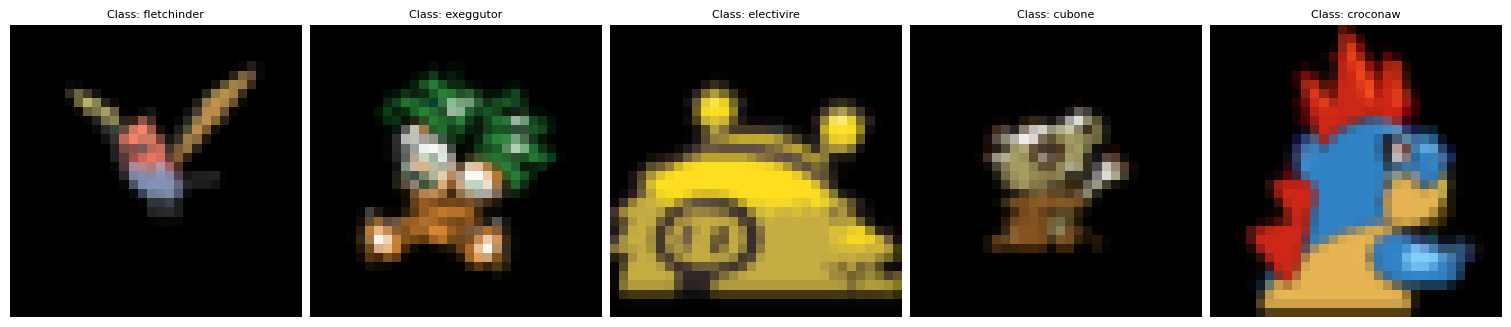

Val 224×224 (ImageNet, TL):


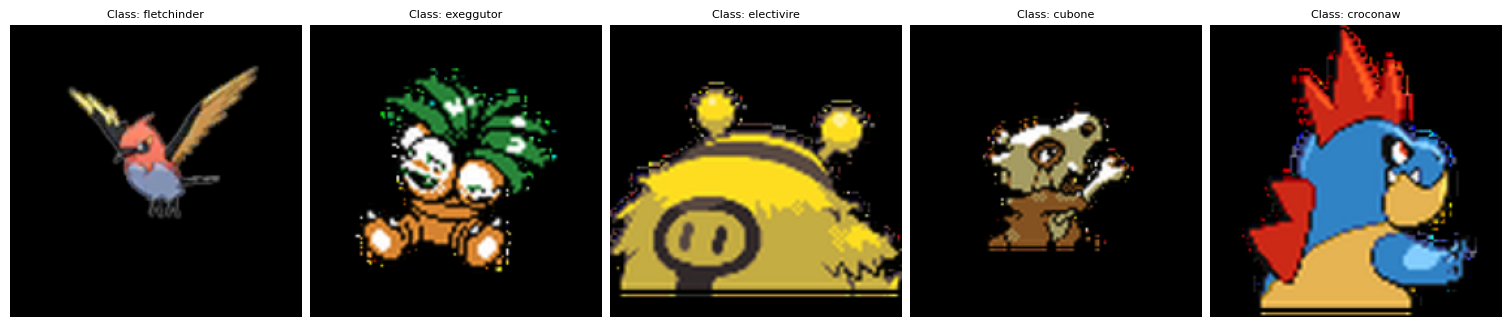

Передбачення найкращої моделі: ResNet18 FT


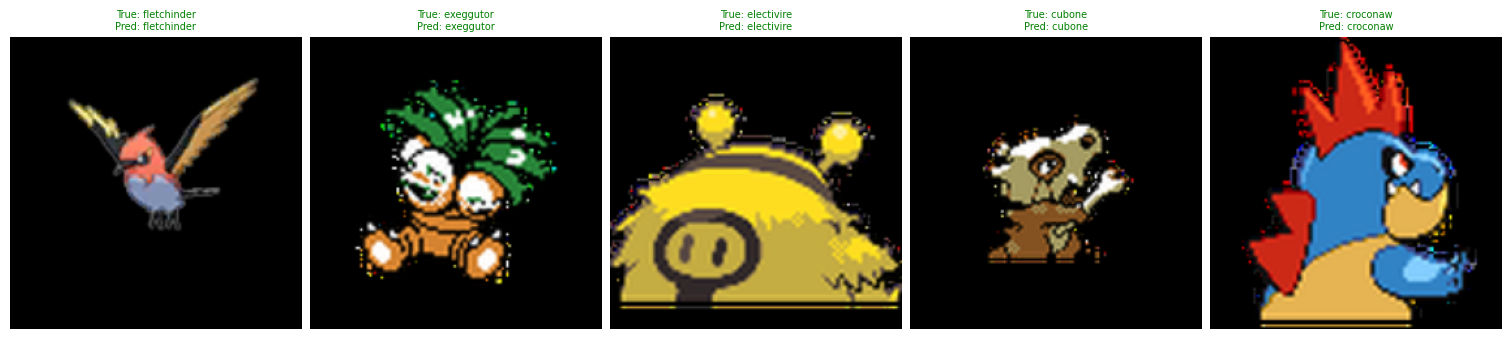

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])


def _to_numpy_hwc(img_chw: np.ndarray, denorm_imagenet: bool) -> np.ndarray:
    img = img_chw.transpose((1, 2, 0))
    if denorm_imagenet:
        img = np.clip(img * IMAGENET_STD + IMAGENET_MEAN, 0, 1)
    else:
        img = np.clip(img * 0.5 + 0.5, 0, 1)
    return img


def visualize_images(
    dataloader: DataLoader,
    class_names: list[str],
    num_images: int = 5,
    denorm_imagenet: bool = False,
) -> None:
    images, labels = next(iter(dataloader))
    n = min(num_images, images.size(0))
    w = min(3 * n, 18)
    fig, axes = plt.subplots(
        1, n, figsize=(w, 6), constrained_layout=True, squeeze=False
    )
    for i in range(n):
        ax = axes[0, i]
        img = images[i].cpu().numpy()
        img = _to_numpy_hwc(img, denorm_imagenet)
        ax.imshow(img, vmin=0, vmax=1)
        idx = int(labels[i].item())
        ax.set_title(f"Class: {class_names[idx]}", fontsize=8)
        ax.axis("off")
    plt.show()


def visualize_predictions(
    model: nn.Module,
    dataloader: DataLoader,
    device: torch.device,
    class_names: list[str],
    num_images: int = 5,
    denorm_imagenet: bool = False,
) -> None:
    model.eval()
    images, labels = next(iter(dataloader))
    with torch.no_grad():
        outputs = model(images.to(device))
        predicted = outputs.argmax(dim=1).cpu().numpy()
    n = min(num_images, images.size(0))
    w = min(3 * n, 18)
    fig, axes = plt.subplots(
        1, n, figsize=(w, 7), constrained_layout=True, squeeze=False
    )
    for i in range(n):
        ax = axes[0, i]
        img = images[i].cpu().numpy()
        img = _to_numpy_hwc(img, denorm_imagenet)
        ax.imshow(img, vmin=0, vmax=1)
        ti = int(labels[i].item())
        pj = int(predicted[i])
        true_label = class_names[ti]
        pred_label = class_names[pj]
        color = "green" if ti == pj else "red"
        ax.set_title(
            f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=7
        )
        ax.axis("off")
    plt.show()


print("Val 32×32 (CNN):")
visualize_images(val_loader, class_names, num_images=5, denorm_imagenet=False)
print("Val 224×224 (ImageNet, TL):")
visualize_images(val_loader_tl, class_names, num_images=5, denorm_imagenet=True)
print("Передбачення найкращої моделі:", best_name)
_, loader_best = models_and_loaders[best_name]
visualize_predictions(
    best_model,
    loader_best,
    device,
    class_names,
    num_images=5,
    denorm_imagenet=best_name not in ("CNNFlatten", "CNNGAP"),
)

**7. Дайте відповіді на контрольні запитання (усно).**


**8. Оформіть звіт.**


**Технічні примітки**

1. Завдання з програмування використовують Python3. Можете користуватися або офіційним дистрибутивом, або дистрибутивом Anaconda, що вже містить більшість заздалегідь встановлених пакетів. Або можете використовувати середовище Google Colab.
2. Щоб працювати з .ipynb-файлами, використовуйте Jupyter. В командному рядку перейдіть у папку з цими файлами та виконайте: jupyter notebook.


**Висновок**

Порівняльна таблиця метрик на валідаційній вибірці (за збереженими результатами експерименту):

| Експеримент    | Час навчання (с) | Найкраща val acc (епоха) | Accuracy (val) | Precision macro | Recall macro | F1 macro | Найкраща train acc |
| -------------- | ---------------: | -----------------------: | -------------: | --------------: | -----------: | -------: | -----------------: |
| CNNFlatten     |             59.2 |                   0.9070 |         0.9070 |          0.8752 |       0.8828 |   0.8675 |             0.9997 |
| CNNGAP         |             55.4 |                   0.5021 |         0.5021 |          0.4469 |       0.4345 |   0.4046 |             0.6148 |
| ResNet18 FE    |            763.7 |                   0.8796 |         0.8796 |          0.8676 |       0.8644 |   0.8516 |             0.9846 |
| ResNet18 FT    |            999.4 |                   0.9521 |         0.9521 |          0.9170 |       0.9243 |   0.9121 |             1.0000 |
| MobileNetV2 FE |            714.5 |                   0.8646 |         0.8646 |          0.8608 |       0.8415 |   0.8379 |             0.9747 |
| MobileNetV2 FT |            736.1 |                   0.6936 |         0.6936 |          0.6964 |       0.6326 |   0.6231 |             0.7964 |

**Найкраща модель.** За критерієм максимального **F1 macro** на валідації обрано **ResNet18 FT** (accuracy 0.9521, precision 0.9170, recall 0.9243, F1 0.9121). Для цієї ж моделі побудовано матрицю плутанини та приклади передбачень.

**Дві ручні CNN (32×32).** За кількістю параметрів: **CNNFlatten** має загалом **400 822** параметрів, з них **307 350** припадає на повнозв’язний шар після Flatten; **CNNGAP** — **112 822** параметрів загалом і лише **19 350** у класифікаторі після Global Average Pooling; різниця **288 000** параметрів, частка GAP до Flatten ≈ **0.281**. Тобто GAP різко зменшує число параметрів у «голові» мережі. За якістю в цьому запуску **CNNFlatten** суттєво перевершив **CNNGAP** (accuracy ≈ 0.91 проти ≈ 0.50): у варіанті з GAP спостерігаються набагато нижчі train/val accuracy та ознаки слабкого навчання або застрягання (на відміну від майже повного запам’ятовування тренінгу у Flatten).

**Transfer Learning (224×224).** **ResNet18 FE** та **MobileNetV2 FE** дають високі, але нижчі за повне доопрацювання результати; **ResNet18 FT** показав найкращі узгоджені метрики. **MobileNetV2 FT** у цьому експерименті виявився гіршим за **MobileNetV2 FE** (accuracy ≈ 0.69 проти ≈ 0.86), що може вказувати на переобучення, неоптимальні гіперпараметри доопрацювання або інші ефекти тонкого налаштування всієї мережі. Навчання попередньо навчених моделей займає порядку **700–1000 с** проти **~55–60 с** для компактних ручних CNN, але дає істотний виграш у точності для найкращої конфігурації.
